<div style="
    font-family: 'Poppins', sans-serif;
    background: linear-gradient(135deg, #001f3f, #003366);
    color: white;
    width: 700px;
    padding: 30px;
    border-radius: 15px;
    margin: 40px auto;
    box-shadow: 0 8px 16px rgba(0, 0, 0, 0.4);
    text-align: center;
    border: 2px solid #00509e;
">
    <h1 style="font-size: 48px; margin-bottom: 20px; text-transform: letter-spacing: 2px; color: #87CEEB;"><strong>Jose Carlos Fernandez</strong><h1>
    <p style="font-size: 22px; margin: 10px 0;"><strong>Matrícula:</strong> 2024-0371</p>
    <p style="font-size: 22px; margin: 10px 0;"><strong>Fecha:</strong> 8 de agoso de 2025</p>
    <p style="font-size: 22px; margin: 10px 0;"><strong>Maestro:</strong> Esloboan Alberto Mora</p>
    <h1 style="font-size: 22px; margin-bottom: 10px; text-transform: letter-spacing: 2px; color: #87CEEB;"><strong>Instituto Tecnológico de Las Américas</strong><h1>

</div>


<div style="
    font-family: 'Poppins', sans-serif;
    background: linear-gradient(135deg, #001f3f, #003366);
    color: white;
    width: 40%;
    padding: 30px;
    border-radius: 15px;
    margin: 40px auto;
    box-shadow: 0 8px 16px rgba(0, 0, 0, 0.4);
    text-align: center;
    border: 2px solid #00509e;
">
    <h2 style="font-size: 28px; margin-bottom: 15px; color: #87CEEB;"><strong>Metodo de Montecarlo</strong></h2>
    <p style="font-size: 18px; margin: 10px 0; font-weight: 500; color: #f0f8ff;">
        Realizado en Python.
    </p>
</div>


<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">


> # **Introduccion al Metodo de Montecarlo**


Hola! En este cuaderno, voy a explorar el Metodo de Montecarlo para resolver problemas matematicos mediante simulaciones probabilisticas. Este metodo es super interesante porque nos permite estimar resultados mediante muestreos aleatorios, lo que lo hace especialmente util para resolver problemas complejos donde los metodos analiticos son dificiles o imposibles.


<hr style=" border: none; border-top: 15px solid #003366; border-radius: 8px; width: 80%; margin: 80px auto; ">


<div style="
    font-family: 'Poppins', sans-serif;
    background: linear-gradient(135deg, #001f3f, #003366);
    color: white;
    width: 40%;
    padding: 30px;
    border-radius: 15px;
    margin: 40px auto;
    box-shadow: 0 8px 16px rgba(0, 0, 0, 0.4);
    text-align: center;
    border: 2px solid #00509e;
">
    <h2 style="font-size: 28px; margin-bottom: 15px; color: #87CEEB;"><strong>Ejercicio 1</strong></h2>
    <p style="font-size: 18px; margin: 10px 0; font-weight: 500; color: #f0f8ff;">
        Estimacion de π (pi).
    </p>
</div>



> **Planteamiento del Problema:**

Tengo que estimar el valor de π usando el Metodo de Montecarlo. La idea es generar puntos aleatorios dentro de un cuadrado unitario y ver cuantos caen dentro de un cuarto de circulo. La proporcion entre estos puntos multiplicada por 4 nos dara una aproximacion de π.

Este enfoque se basa en la relacion entre el area de un circulo de radio 1 (π) y el area de un cuadrado de lado 2 (4).

Vamos a ver como funciona en la practica!


> **Importar las librerias necesarias ⬇️**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm  # Para mostrar una barra de progreso
import time
from scipy.stats import binom # Para distribucion binomial

# ====================================

# Configuramos el estilo visual de los futuros graficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
np.random.seed(356)  # Para reproducibilidad

> **Hacemos una funcion para estirmar pi, para que sea reproducible en futuros ejercicios ⬇️**

In [ ]:
def estimate_pi(n_points):
    # Paso 1: Generar puntos aleatorios en el cuadrado unitario
    x = np.random.uniform(0, 1, n_points)
    y = np.random.uniform(0, 1, n_points)

    # Paso 2: Calcular distancia al origen (0,0)
    distance = np.sqrt((x - 0) ** 2 + (y - 0) ** 2)

    # Paso 3: Contar puntos dentro del cuarto de circulo (distancia <= 1)
    points_inside = np.sum(distance <= 1)

    # Paso 4: Saber que la proporcion multiplicada por 4 nos da pi
    pi_estimate = 4 * points_inside / n_points

    return pi_estimate, x, y, distance


# Paso 5: Indicar el numero de simulaciones
n_simulations = 10000

# Paso 6: Estimar pi
start_time = time.time()
pi_estimate, x, y, distance = estimate_pi(n_simulations)
end_time = time.time()

# Paso 7: Calcular el error absoluto
error = abs(pi_estimate - np.pi)

> **Visualizacion de los resultados ⬇️**

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


🔵 Valor estimado de π (pi): 3.135600
🟢 Valor real de π (pi):     3.141593
🔴 Error absoluto:      0.005993


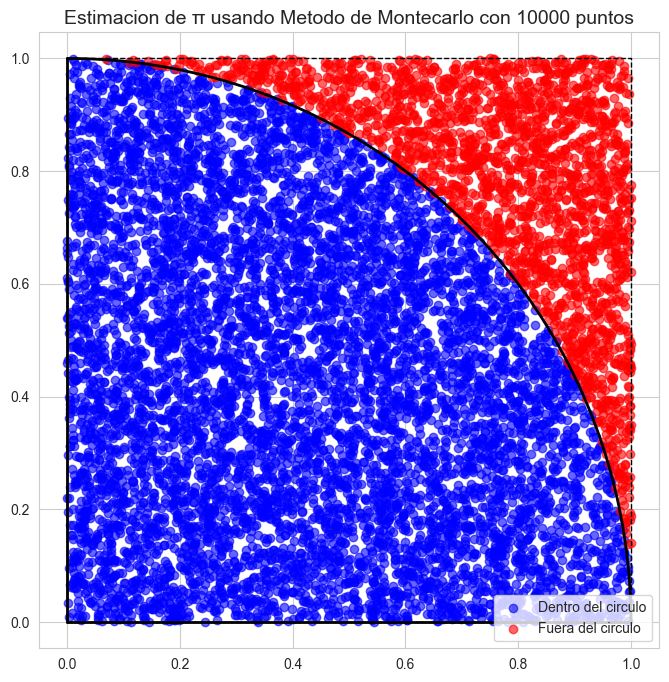

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(
    x[distance <= 1],
    y[distance <= 1],
    color="blue",
    alpha=0.6,
    label="Dentro del circulo",
)
plt.scatter(
    x[distance > 1], y[distance > 1], color="red", alpha=0.6, label="Fuera del circulo"
)
plt.plot([0, 1], [0, 0], "k-", lw=2)
plt.plot([0, 0], [0, 1], "k-", lw=2)
plt.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], "k--", lw=1)

# Dibujamos un arco para representar el cuarto de circulo
theta = np.linspace(0, np.pi / 2, 100)
plt.plot(np.cos(theta), np.sin(theta), "k-", lw=2)

plt.axis("equal")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.legend()
plt.title(
    f"Estimacion de π usando Metodo de Montecarlo con {n_simulations} puntos", fontsize=14
)

# Mostrar los resultados numericos
print(
    f"🔵 Valor estimado de π (pi): {pi_estimate:.6f}"
)  # Redondeado a 6 decimales para ver que tanto se acerca
print(f"🟢 Valor real de π (pi):     {np.pi:.6f}")
print(f"🔴 Error absoluto:      {error:.6f}")

> # **Convergencia del Metodo**

La **convergencia** en el contexto del método de Monte Carlo se refiere a cómo nuestras estimaciones se aproximan cada vez más al valor real a medida que aumentamos el número de puntos o muestras en nuestra simulación.

Ahora voy a ver como converge la estimacion a medida que aumenta el numero de puntos. Esto me ayudara a entender mejor la precision del metodo:


100%|██████████| 50/50 [00:00<00:00, 2091.63it/s]


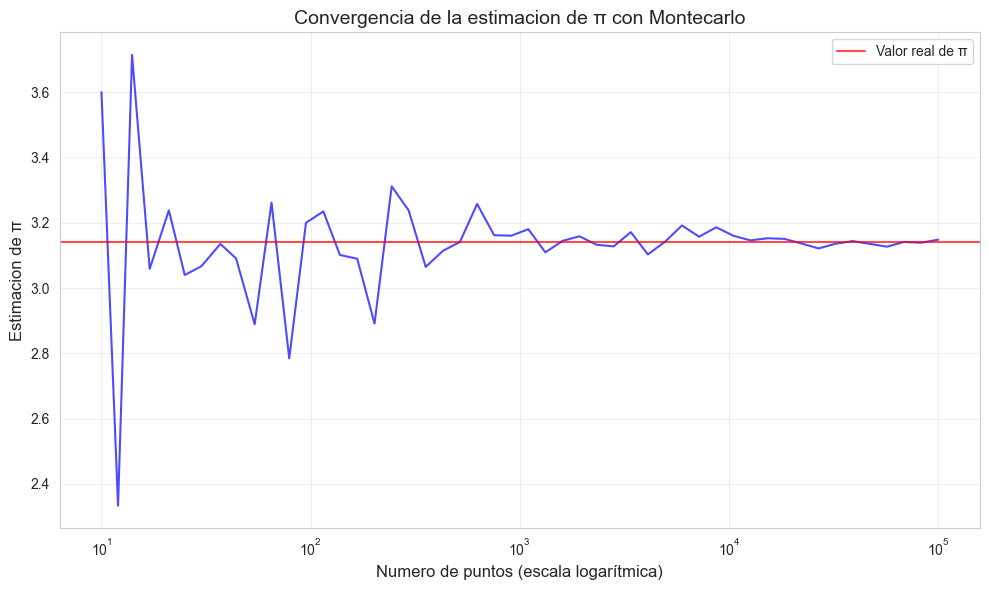

In [33]:
# Estudio de la convergencia:


steps = np.logspace(1, 5, 50).astype(int)  # Desde 10 hasta 100,000 puntos
pi_estimates = []

for n in tqdm(steps):
    x = np.random.random(n)
    y = np.random.random(n)
    distance = np.sqrt(x**2 + y**2)
    points_inside = np.sum(distance <= 1)
    pi_estimates.append((points_inside / n) * 4)

# Graficamos la convergencia
plt.figure(figsize=(10, 6))
plt.semilogx(steps, pi_estimates, "b-", alpha=0.7)
plt.axhline(np.pi, color="r", linestyle="-", alpha=0.7, label="Valor real de π")
plt.xlabel("Numero de puntos (escala logarítmica)", fontsize=12)
plt.ylabel("Estimacion de π", fontsize=12)
plt.title("Convergencia de la estimacion de π con Montecarlo", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Interesante! He estimado el valor de π usando el metodo de `Montecarlo con 10,000 simulaciones`. Como pueden ver en el grafico, los puntos azules estan dentro del circulo y los rojos fuera. La relacion entre puntos dentro del circulo y el total me da mi aproximacion.

En el segundo grafico, vean como la linea azul va cambiando en la estimacion, hasta llegar a un punto bastante cerca a la linea roja, la cual es el valor real de π, o sea, la estimacion se acerca bastante al valor real.

El `error absoluto` nos muestra que tan cerca estamos del `valor real de π`. Si quisieramos obtener una mejor aproximacion, podriamos aumentar el numero de simulaciones, aunque eso aumentaria el tiempo de ejecucion.


<hr style=" border: none; border-top: 15px solid #003366; border-radius: 8px; width: 80%; margin: 80px auto; ">


<div style="
    font-family: 'Poppins', sans-serif;
    background: linear-gradient(135deg, #001f3f, #003366);
    color: white;
    width: 40%;
    padding: 30px;
    border-radius: 15px;
    margin: 40px auto;
    box-shadow: 0 8px 16px rgba(0, 0, 0, 0.4);
    text-align: center;
    border: 2px solid #00509e;
">
    <h2 style="font-size: 28px; margin-bottom: 15px; color: #87CEEB;"><strong>Ejercicio 2</strong></h2>
    <p style="font-size: 18px; margin: 10px 0; font-weight: 500; color: #f0f8ff;">
        Problema de Probabilidad
    </p>
</div>


> **Planteamiento del Problema:**

Una fabrica produce piezas con un 3% de defectos. Tengo que simular el proceso de inspeccion de 1,000 lotes de 50 piezas cada uno para estimar la probabilidad de que un lote contenga mas de 2 piezas defectuosas.

Este es un problema perfecto para el metodo de Montecarlo, ya que puedo simular muchos lotes y contar cuantos tienen mas de 2 defectos!


> **Funcion para simular lotes ⬇️**

In [ ]:
def simulate_lots(n_lots, lot_size, defect_probability):
    """
    Simula n_lots de lot_size piezas cada una y calcula
    la probabilidad de que un lote tenga mas de 2 piezas defectuosas.

    Usamos un enfoque de simulacion para estimar esta probabilidad.

    Parametros:
    - n_lots: Numero de lotes a simular
    - lot_size: Numero de piezas por lote
    - defect_probability: Probabilidad de que una pieza sea defectuosa
    """

    # Simular n_lots de lot_size piezas cada uno
    # Para cada pieza, determinar si es defectuosa basado en defect_probability
    defects_per_lot = np.random.binomial(lot_size, defect_probability, n_lots)

    # Contar lotes con mas de 2 piezas defectuosas
    lots_with_more_than_2_defects = np.sum(defects_per_lot > 2)

    # Calcular la probabilidad estimada
    probability = lots_with_more_than_2_defects / n_lots

    return probability, defects_per_lot

> **Parametros del problema ⬇️**

In [ ]:
n_lots = 1000  # Numero de lotes
lot_size = 50  # Piezas por lote
defect_probability = 0.03  # Probabilidad de defecto (3%)

# Ejecutar simulacion
start_time = time.time()
probability, defects_per_lot = simulate_lots(n_lots, lot_size, defect_probability)
end_time = time.time()

# Calcular probabilidad teorica usando distribucion binomial
theoretical_prob = 1 - binom.cdf(2, lot_size, defect_probability)

> **Muestreo de resultados ⬇️**

In [52]:
print(f"➡️ Probabilidad estimada de mas de 2 defectos por lote: {probability:.6f}")
print(f"➡️ Probabilidad teorica: {theoretical_prob:.6f}")
print(f"➡️ Error absoluto: {abs(probability - theoretical_prob):.6f}")
print(f"➡️ Tiempo de ejecucion: {end_time - start_time:.4f} segundos")

➡️ Probabilidad estimada de mas de 2 defectos por lote: 0.180000
➡️ Probabilidad teorica: 0.189202
➡️ Error absoluto: 0.009202
➡️ Tiempo de ejecucion: 0.0010 segundos


> **Visualizacion de la distribucion de defectos ⬇️**

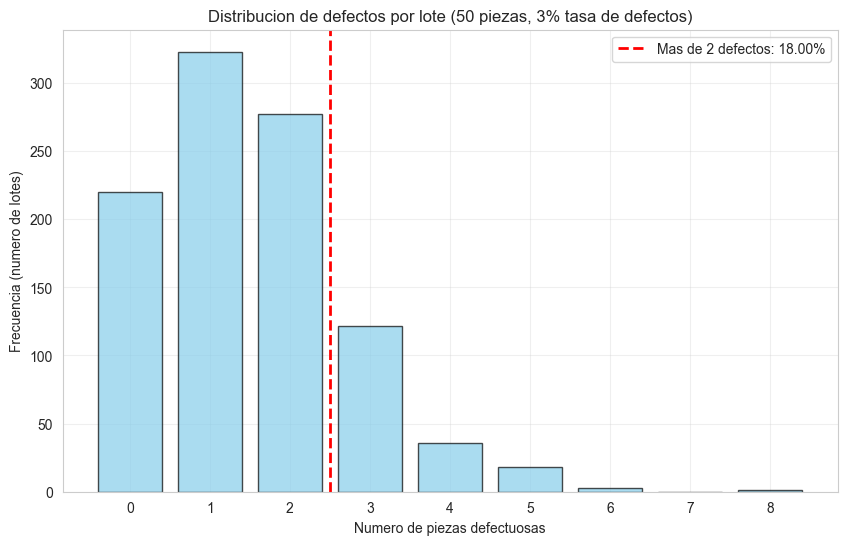

In [37]:
plt.figure(figsize=(10, 6))
counts, bins, patches = plt.hist(
    defects_per_lot,
    bins=np.arange(-0.5, max(defects_per_lot) + 1.5, 1),  # Centra las barras
    alpha=0.7,
    color="skyblue",
    edgecolor="black",
    rwidth=0.8,
)

# Añadir linea para separar más de 2 defectos
plt.axvline(
    x=2.5,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mas de 2 defectos: {probability:.2%}",
)

plt.title("Distribucion de defectos por lote (50 piezas, 3% tasa de defectos)")
plt.xlabel("Numero de piezas defectuosas")
plt.ylabel("Frecuencia (numero de lotes)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(range(0, max(defects_per_lot) + 1))
plt.show()

- En este ejercicio he simulado 1,000 lotes de 50 piezas cada uno, donde cada pieza tiene una probabilidad del 3% de ser defectuosa.

- Como pueden ver en el histograma, la mayoria de los lotes tienen entre 0 y 2 piezas defectuosas, pero hay un numero significativo con mas de 2 (representado por la linea roja).

- La probabilidad estimada mediante la simulacion es muy cercana a la probabilidad teorica calculada usando la distribucion binomial. Esto demuestra el `poder del metodo Monte Carlo` para estimar probabilidades complejas sin necesidad de calculos matematicos avanzados.

<hr style=" border: none; border-top: 15px solid #003366; border-radius: 8px; width: 80%; margin: 80px auto; ">

<div style="
    font-family: 'Poppins', sans-serif;
    background: linear-gradient(135deg, #001f3f, #003366);
    color: white;
    width: 40%;
    padding: 30px;
    border-radius: 15px;
    margin: 40px auto;
    box-shadow: 0 8px 16px rgba(0, 0, 0, 0.4);
    text-align: center;
    border: 2px solid #00509e;
">
    <h2 style="font-size: 28px; margin-bottom: 15px; color: #87CEEB;"><strong>Ejercicio 3</strong></h2>
    <p style="font-size: 18px; margin: 10px 0; font-weight: 500; color: #f0f8ff;">
        Evaluacion de una integral.
    </p>
</div>


En este ejercicio voy a estimar el valor de la integral definida: `∫₀¹ e^(−x²) dx` usando el metodo de Monte Carlo.

In [38]:
# Definicion de las funciones

def f(x):
    """Funcion a integrar: e^(-x^2)
    - Esta funcion representa la forma de campana de la distribucion normal.
    """
    return np.exp(-x**2)

def monte_carlo_integration(func, a, b, n_points):
    """
    Realiza la integracion de Monte Carlo de una funcion en un intervalo [a,b].

    Parametros:
    - func: La funcion a integrar
    - a: Limite inferior del intervalo
    - b: Limite superior del intervalo
    - n_points: Numero de puntos aleatorios a generar

    Retorna:
    - La estimacion de la integral
    - Los puntos x generados
    - Los valores y correspondientes
    """
    
    # Generamos los puntos aleatorios en [a,b]
    x = np.random.uniform(a, b, n_points)
    
    # Evaluamos la funcion en esos puntos
    y = func(x)
    
    # La integral es igual al area promedio * el ancho del intervalo
    integral_estimate = (b - a) * np.mean(y)
    
    return integral_estimate, x, y

> **Parametros ⬇️**

In [ ]:
a, b = 0, 1  # Limites de integracion
n_simulations = 5000  # Numero de simulaciones

# Estimamos la integral
start_time = time.time()
integral_estimate, x_points, y_values = monte_carlo_integration(f, a, b, n_simulations)
end_time = time.time()

# Calculamos el valor real de la integral para comparar
from scipy import special
real_value = 0.5 * special.erf(1) * np.sqrt(np.pi)

# Calculamos el error absoluto
error = abs(integral_estimate - real_value)

> **Muestreo de resultados ⬇️**

In [55]:
print(f"🔵 Estimación de la integral con {n_simulations} simulaciones: {integral_estimate:.6f}")
print(f"🔴 Valor real de la integral: {real_value:.6f}")
print(f"🟢 Error absoluto: {error:.6f}")
print(f"🟡 Tiempo de ejecución: {end_time - start_time:.4f} segundos")

🔵 Estimación de la integral con 5000 simulaciones: 0.745542
🔴 Valor real de la integral: 0.746824
🟢 Error absoluto: 0.001282
🟡 Tiempo de ejecución: 0.0010 segundos


> **Visualizacion de la integracion ⬇️**

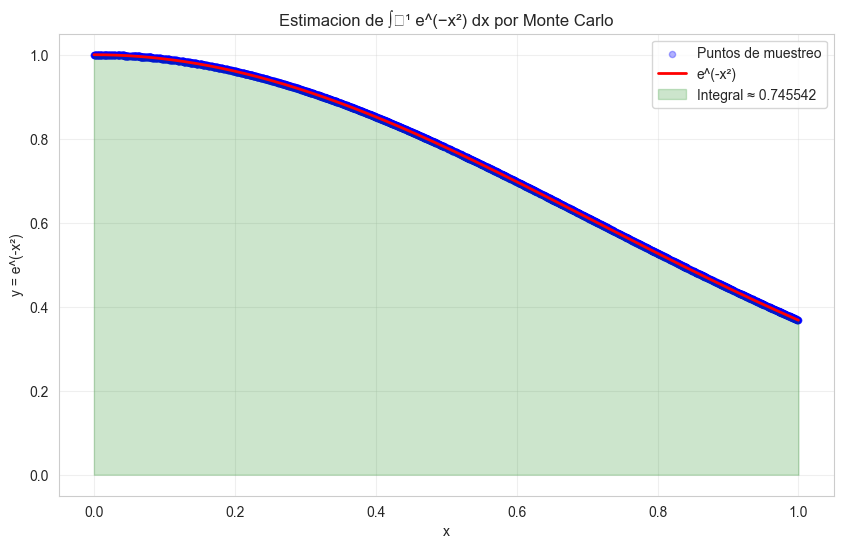

In [54]:
plt.figure(figsize=(10, 6))

# Puntos usados en la integracion
plt.scatter(x_points, y_values, alpha=0.3, color='blue', s=20, label='Puntos de muestreo')

# Graficamos la funcion
x_plot = np.linspace(a, b, 1000)
y_plot = f(x_plot)
plt.plot(x_plot, y_plot, 'r-', linewidth=2, label='e^(-x²)')

# Area bajo la curva
plt.fill_between(x_plot, y_plot, alpha=0.2, color='green', label=f'Integral ≈ {integral_estimate:.6f}')

plt.title('Estimacion de ∫₀¹ e^(−x²) dx por Monte Carlo')
plt.xlabel('x')
plt.ylabel('y = e^(-x²)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

> # **Convergencia del metodo**

La **convergencia** en el contexto del metodo de Monte Carlo se refiere a como nuestras estimaciones se aproximan cada vez mas al valor real a medida que aumentamos el número de puntos o muestras en nuestra simulacion.

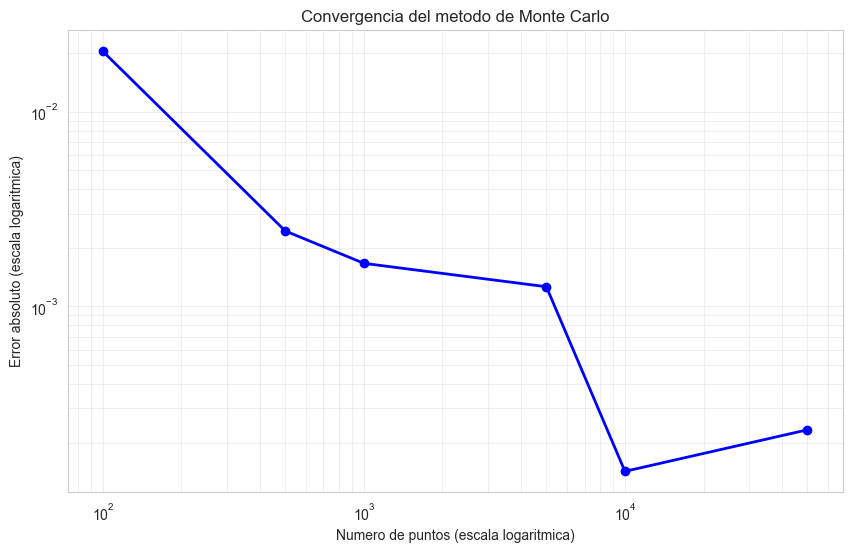

In [42]:
# Analizamos ahora la convergencia del metodo
n_values = [100, 500, 1000, 5000, 10000, 50000]
estimates = []
errors = []

for n in n_values:
    estimate, _, _ = monte_carlo_integration(f, a, b, n)
    estimates.append(estimate)
    errors.append(abs(estimate - real_value))

plt.figure(figsize=(10, 6))
plt.loglog(n_values, errors, 'bo-', linewidth=2)
plt.xlabel('Numero de puntos (escala logaritmica)')
plt.ylabel('Error absoluto (escala logaritmica)')
plt.title('Convergencia del metodo de Monte Carlo')
plt.grid(True, which='both', alpha=0.3)
plt.show()

- En este ejercicio he estimado el valor de la integral `∫₀¹ e^(−x²) dx` utilizando el metodo de Monte Carlo. La idea es `generar puntos aleatorios en el intervalo [0,1]` y evaluar la funcion en esos puntos. El promedio de estos valores multiplicado por el ancho del intervalo me da una `aproximacion de la integral`.

- Como pueden ver en el grafico, he representado la funcion `e^(-x²)` en rojo y los puntos de muestreo en azul. El area sombreada en verde representa la integral estimada.

- Tambien he incluido un analisis de convergencia que muestra como el error disminuye conforme aumentamos el numero de puntos. Este es un comportamiento tipico del metodo de Monte Carlo, donde el `error disminuye proporcionalmente` a `1/√n`, donde `n es el numero de puntos`.

<hr style=" border: none; border-top: 15px solid #003366; border-radius: 8px; width: 80%; margin: 80px auto; ">

<div style="
    font-family: 'Poppins', sans-serif;
    background: linear-gradient(135deg, #001f3f, #003366);
    color: white;
    width: 40%;
    padding: 30px;
    border-radius: 15px;
    margin: 40px auto;
    box-shadow: 0 8px 16px rgba(0, 0, 0, 0.4);
    text-align: center;
    border: 2px solid #00509e;
">
    <h2 style="font-size: 28px; margin-bottom: 15px; color: #87CEEB;"><strong>BONUS</strong></h2>
    <p style="font-size: 18px; margin: 10px 0; font-weight: 500; color: #f0f8ff;">
        Simulacion interactiva del ejercicio 1 (estimacion de π pi)
    </p>
</div>


Ahora vamos a crear una version interactiva del estimador de π, donde podemos ajustar el numero de puntos y ver como mejora la precision.

In [ ]:
def interactive_pi_estimation():
    """Funcion para la estimacion interactiva de π usando el método de Monte Carlo

    Esta funcion permite al usuario ingresar el numero de puntos a utilizar en la simulacion
    y muestra los resultados de la estimacion de π, incluyendo graficos de dispersion y
    convergencia.
    """

    # Solicitar el numero de puntos al usuario
    try:
        n_points = int(
            input(
                "Ingrese el numero de puntos para la simulacion (recomendado: entre 1000 y 100000): "
            )
        )
        if n_points <= 0:
            print("El numero debe ser positivo. Usando 10000 por defecto.")
            n_points = 10000
    except ValueError:
        print("Entrada invalida. Usando 10000 por defecto.")
        n_points = 10000

    print(f"\nEjecutando simulacion con {n_points} puntos...")

    # Realizar la estimacion
    start_time = time.time()
    pi_estimate, x, y, distance = estimate_pi(n_points)
    end_time = time.time()

    # Mostrar resultados
    print("\nResultados:")
    print(f"🔵Estimacion de π: {pi_estimate:.6f}")
    print(f"🔴Valor real de π: {np.pi:.6f}")
    print(f"🟢Error absoluto: {abs(pi_estimate - np.pi):.2f}")
    print(f"🔵Error relativo: {abs(pi_estimate - np.pi) / np.pi * 100:.2f}%")
    print(f"🟡Tiempo de ejecucion: {end_time - start_time:.4f} segundos")

    # Visualizar resultados con mas detalle
    plt.figure(figsize=(15, 6))

    # Subplot 1: Puntos en el cuadrante
    plt.subplot(1, 2, 1)
    inside_circle = distance <= 1
    outside_circle = distance > 1

    plt.scatter(
        x[inside_circle],
        y[inside_circle],
        color="blue",
        alpha=0.5,
        s=10,
        label="Dentro",
    )
    plt.scatter(
        x[outside_circle],
        y[outside_circle],
        color="red",
        alpha=0.5,
        s=10,
        label="Fuera",
    )

    theta = np.linspace(0, np.pi / 2, 100)
    circle_x = np.cos(theta)
    circle_y = np.sin(theta)
    plt.plot(circle_x, circle_y, "g-", linewidth=2)

    plt.axis("square")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.title(f"Estimacion de π: {pi_estimate:.6f}")
    plt.legend()

    # Subplot 2: Convergencia
    plt.subplot(1, 2, 2)

    # Simular la convergencia en diferentes puntos
    sample_sizes = np.logspace(1, np.log10(n_points), 20).astype(int)
    pi_estimates = []

    for size in sample_sizes:
        pi_est, _, _, _ = estimate_pi(size)
        pi_estimates.append(pi_est)

    plt.semilogx(sample_sizes, pi_estimates, "bo-", alpha=0.7)
    plt.axhline(y=np.pi, color="r", linestyle="--", label=f"π real: {np.pi:.6f}")
    plt.axhline(
        y=pi_estimate, color="g", linestyle="-", label=f"Estimacion: {pi_estimate:.6f}"
    )
    plt.grid(True)
    plt.title("Convergencia de la estimacion")
    plt.xlabel("Numero de puntos (escala log)")
    plt.ylabel("Estimacion de π")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Preguntar si desea continuar
    retry = input("\n¿Desea realizar otra simulacion? (s/n): ").lower()
    if retry == "s":
        interactive_pi_estimation()
    else:
        print("¡Gracias por usar el simulador de Montecarlo! Hecho por JC📊")

> **Llamamos a la funcion ⬇️**


Ejecutando simulacion con 69000 puntos...

Resultados:
🔵Estimacion de π: 3.144754
🔴Valor real de π: 3.141593
🟢Error absoluto: 0.00
🔵Error relativo: 0.10%
🟡Tiempo de ejecucion: 0.0030 segundos


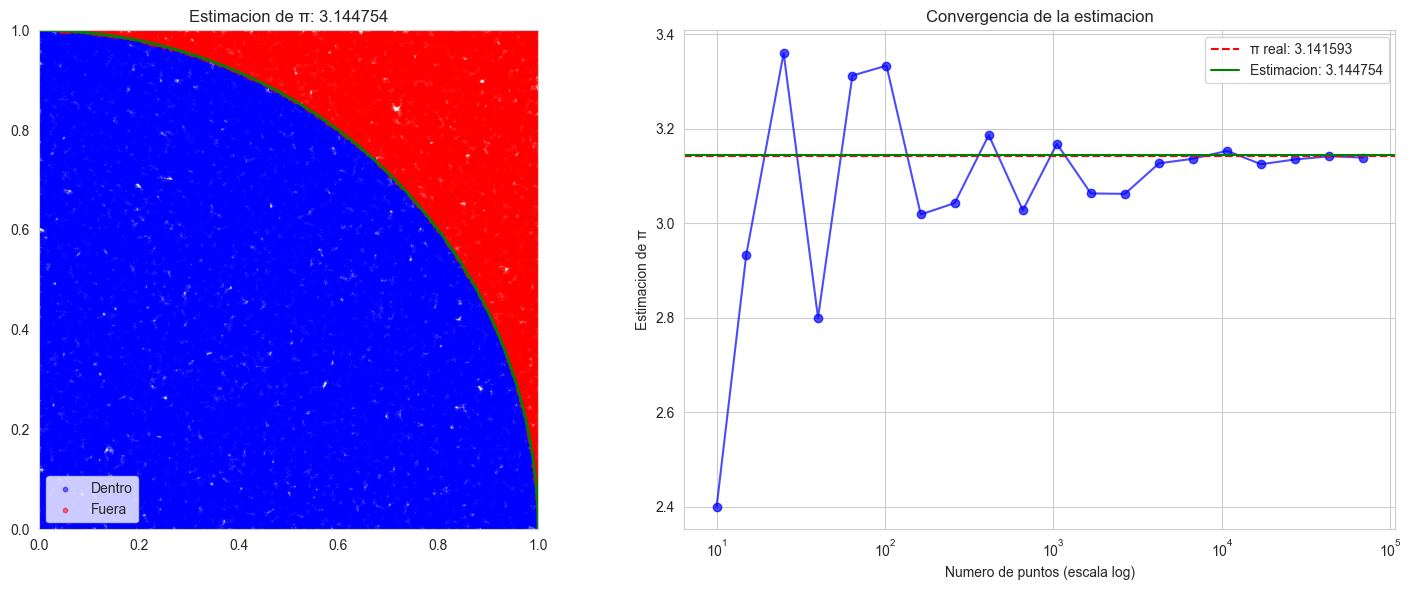

¡Gracias por usar el simulador de Montecarlo! Hecho por JC📊


In [ ]:
interactive_pi_estimation()

- En este bonus he creado una version interactiva del estimador de π. Puedes ingresar el numero de puntos que desees y el programa te mostrara la estimacion junto con graficos de visualizacion.

- A la izquierda, veras los puntos generados aleatoriamente (azules si estan dentro del circulo, rojos si estan fuera). A la derecha, veras un grafico de convergencia que muestra como la estimacion se acerca al valor real de π conforme aumenta el numero de puntos.

<hr style=" border: none; border-top: 15px solid #003366; border-radius: 8px; width: 80%; margin: 80px auto; ">

> # **Conclusiones** 

**A traves de estos ejercicios, he demostrado el poder y la versatilidad del metodo de Montecarlo para resolver diferentes tipos de problemas:**

- **Estimacion de constantes matematicas**: Como vimos en el ejercicio 1, podemos estimar π con bastante precision.

- **Calculo de probabilidades**: El ejercicio 2 mostro como podemos simular eventos aleatorios para estimar probabilidades complejas.

- **Evaluacion de integrales**: En el ejercicio 3, evaluamos una integral que seria dificil de calcular analiticamente.

**El metodo de Montecarlo es especialmente util cuando**:

- Los problemas tienen muchas dimensiones
- La solucion analitica es dificil o imposible de encontrar
- Queremos una aproximacion rapida con un error controlado
- La precision del metodo aumenta con el numero de simulaciones, aunque el error tipicamente disminuye a una tasa de 1/√n, lo que significa que para reducir el error a la mitad, necesitamos cuadruplicar el numero de simulaciones.

Nuevamente, agradeciendo al profesor por este reto que me hizo crecer como analista de datos, aprendiendo un nuevo metodo para resolver problemas, lo cual es algo que vale mas que oro para alguien que viva de resolver problemas, como un analista de datos.

<div style="display: flex; justify-content: center; align-items: center; height: 300px;">
    <div style="background: linear-gradient(135deg, #28a745, #218838); color: white; width: 600px; height: 300px; border-radius: 30px; box-shadow: 0 8px 16px rgba(0, 0, 0, 0.3); font-size: 64px; font-weight: bold; text-align: center; display: flex; justify-content: center; align-items: center; border: 4px solid #1e7e34; position: relative;">
        <span style="text-shadow: 2px 2px 8px rgba(0, 0, 0, 0.5);">FIN</span>
        <p style="position: absolute; bottom: 15px; font-size: 14px; color: rgba(255, 255, 255, 0.7); font-style: italic;">Jose Carlos Fernandez</p>
    </div>
</div>